In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, random
import warnings
warnings.filterwarnings('ignore')

# **1. Data Preparing**

## **1.1 Load Data**

In [2]:
os.chdir('/Users/lotus/Desktop/IBM-HR-Analytics-Employee-Attrition-Performance')

In [3]:
# Load the preprocessed and scaled data
df = pd.read_csv('data/HR_cleaned_scaled.csv')

In [4]:
print(df.shape)
print(df.columns)
df.head()

(1470, 46)
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_yes',
       'BusinessTravel_travel_frequently', 'BusinessTravel_travel_rarely',
       'Department_research & development', 'Department_sales', 'Gender_male',
       'JobRole_human resources', 'JobRole_laboratory technician',
       'JobRole_manager', 'JobRole_manufacturing director',
       'JobRole_research director', 'JobRole_research scientist',
       'JobRole_sales executive', 'JobRole_sales representative',
       'MaritalStatus_married', 'MaritalStatus_si

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_sales executive,JobRole_sales representative,MaritalStatus_married,MaritalStatus_single,OverTime_yes,EducationField_life sciences,EducationField_marketing,EducationField_medical,EducationField_other,EducationField_technical degree
0,0.446350,0.742527,-1.010909,-0.891688,-1.701283,-0.660531,1.383138,0.379672,-0.057788,1.153254,...,True,False,False,True,True,True,False,False,False,False
1,1.322365,-1.297775,-0.147150,-1.868426,-1.699621,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,...,False,False,True,False,False,True,False,False,False,False
2,0.008343,1.414363,-0.887515,-0.891688,-1.696298,1.169781,1.284725,-1.026167,-0.961486,0.246200,...,False,False,False,True,True,False,False,False,True,False
3,-0.429664,1.461466,-0.764121,1.061787,-1.694636,1.169781,-0.486709,0.379672,-0.961486,0.246200,...,False,False,True,False,True,True,False,False,False,False
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.691313,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,...,False,False,True,False,False,False,False,True,False,False


## **1.2 Split Data**

In [85]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Attrition_yes', axis=1)
y = df['Attrition_yes']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1249, 45)
Shape of X_test: (221, 45)
Shape of y_train: (1249,)
Shape of y_test: (221,)


# **2. Basic ML Model**

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import xgboost as xgb
import lightgbm as lgb
from sklearn.svm import SVC
from lightgbm.callback import early_stopping as lgb_early_stopping

In [156]:
# training function with grid search and early stop
def model_train(model_name, X_train_full, y_train_full, X_test, y_test, early_stopping_rounds = 20):

    print(f"---训练模型: {model_name} ---")

    # 若使用早停需要再次划分训练集和验证集
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
    )

    # 定义每个模型的参数网络
    if model_name == 'XGBoost':
        model = xgb.XGBClassifier(
            objective='binary:logistic', eval_metric='logloss', use_label_encoder=False,
            random_state=42, n_jobs=-1
        )
        param_grid = {
            'n_estimators': [1000],
            'learning_rate': [0.05, 0.1],
            'max_depth': [3, 5], # 减小最大深度（强正则）
            'lambda': [0.1, 1], # L2
            'alpha': [0.5]  # L1
        }

    elif model_name == 'LightGBM':
        model = lgb.LGBMClassifier(
            objective='binary', metric='auc', boosting_type='gbdt',
            random_state=42, n_jobs=-1
        )
        param_grid = {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.05, 0.1],
            'max_depth': [-1, 5],
            'num_leaves': [10, 31],
        }

    elif model_name == 'RandomForest':
        model = RandomForestClassifier(random_state=42, n_jobs=-1)
        param_grid = {
            'n_estimators': [150],             # 减少树的数量
            'warm_start': [True],                       # 启用增量训练
            'max_depth': [4],                      # 严格限制最大深度
            'min_samples_leaf': [9],           # 增加叶子节点的最小样本数，防止过拟合
            'min_samples_split': [10]    # 增加拆分节点的最小样本数
            }

    elif model_name == 'SVM':
        model = SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced')
        param_grid = {
            'C': [0.1, 1],          # 正则化参数
            'gamma': ['scale', 0.1] # 核函数系数
        }

    else:
        raise ValueError("请输入已经定义的模型名称: 'XGBoost', 'LightGBM', 'RandomForest', 'SVM'.")

    # 使用 StratifiedKFold 确保交叉验证中类别比例保持一致
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # 使用GridSearch+cv找到最优模型
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='roc_auc',  # 基于auc筛选
        cv=kf,
        verbose=1,
        n_jobs=-1
    )

    grid_search.fit(X_train_full, y_train_full)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    print(f"\n Grid Search 最佳参数: {best_params}")
    print(f"\n 交叉验证最佳 AUC-ROC: {best_score:.4f}")

    final_model = model.set_params(**best_params)
    if model_name == 'XGBoost':
        try:
            # 尝试使用早停
            final_model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                eval_metric='logloss',
                early_stopping_rounds = early_stopping_rounds,
                verbose=False
            )
            try:
                best_iter = final_model.best_iteration
            except AttributeError:
                best_iter = "N/A (Early Stop)"

            print(f"XGBoost 模型使用早停策略训练完成。最佳迭代轮次: {best_iter}")

        except TypeError: # 早停失败 使用完整的训练集
            final_model.fit(X_train_full, y_train_full, verbose=False)
            print("XGBoost 模型完整训练完成")

    elif model_name == 'LightGBM':
        final_model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb_early_stopping(early_stopping_rounds, verbose=False)]
        )
        print(f"LightGBM 模型使用早停策略训练完成。最佳迭代轮次: {final_model.best_iteration_}")

    else: # 其余模型不使用早停 直接用最优模型
        final_model = grid_search.best_estimator_
        final_model.fit(X_train_full, y_train_full)
        print(f"{model_name} 模型完整训练完成")

    return final_model, best_params

---训练模型: RandomForest ---
Fitting 5 folds for each of 1 candidates, totalling 5 fits

 Grid Search 最佳参数: {'max_depth': 4, 'min_samples_leaf': 9, 'min_samples_split': 10, 'n_estimators': 150, 'warm_start': True}

 交叉验证最佳 AUC-ROC: 0.9285
RandomForest 模型完整训练完成

---RandomForest 性能评估 ---

 Training Set Metrics:
  Accuracy:  0.8808
  Precision: 0.9241
  Recall:    0.8067
  F1-Score:  0.8614
  AUC-ROC:   0.9448

 Testing Set Metrics:
  Accuracy:  0.8235
  Precision: 0.4571
  Recall:    0.4444
  F1-Score:  0.4507
  AUC-ROC:   0.8111

--- 测试集混淆矩阵 (Confusion Matrix) ---


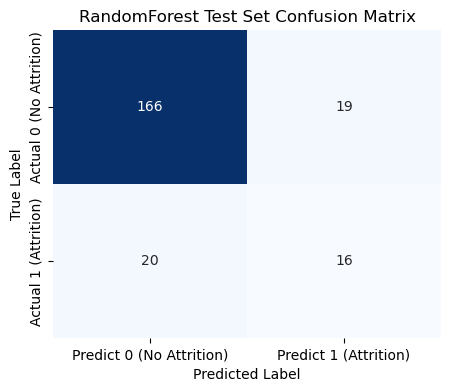

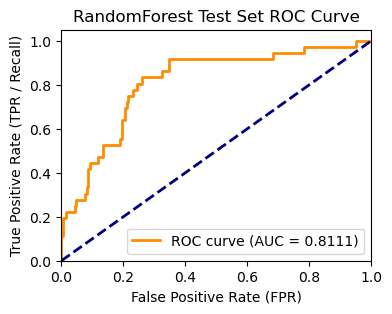

In [157]:
# 建立随机森林模型
model_name_lasso_rf = 'RandomForest'
best_lasso_rf_model, best_lasso_rf_params = model_train(
    model_name_lasso_rf,
    X_resampled_lasso, y_resampled_lasso,
    X_test_lasso, y_test
)

model_evaluation(
    best_lasso_rf_model,
    X_resampled_lasso, y_resampled_lasso,
    X_test_lasso, y_test,
    model_name_lasso_rf
)

In [23]:
def model_evaluation(model, X_train, y_train, X_test, y_test, model_name):

    datasets = {
        'Training': (X_train, y_train),
        'Testing': (X_test, y_test)
    }

    results = {}

    print(f"\n---{model_name} 性能评估 ---")

    for name, (X, y) in datasets.items():
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)[:, 1]

        results[name] = {
            'Accuracy': accuracy_score(y, y_pred),
            'Precision': precision_score(y, y_pred),
            'Recall': recall_score(y, y_pred),
            'F1-Score': f1_score(y, y_pred),
            'AUC-ROC': roc_auc_score(y, y_prob),
            'y_pred': y_pred,
            'y_prob': y_prob
        }

        print(f"\n {name} Set Metrics:")
        print(f"  Accuracy:  {results[name]['Accuracy']:.4f}")
        print(f"  Precision: {results[name]['Precision']:.4f}")
        print(f"  Recall:    {results[name]['Recall']:.4f}")
        print(f"  F1-Score:  {results[name]['F1-Score']:.4f}")
        print(f"  AUC-ROC:   {results[name]['AUC-ROC']:.4f}")

    print("\n--- 测试集混淆矩阵 (Confusion Matrix) ---")
    cm = confusion_matrix(y_test, results['Testing']['y_pred'])

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predict 0 (No Attrition)', 'Predict 1 (Attrition)'],
                yticklabels=['Actual 0 (No Attrition)', 'Actual 1 (Attrition)'])
    plt.title(f'{model_name} Test Set Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    file_name = f"plt/{model_name}_Confusion_Matrix.png"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    plt.show()


    # 绘制 ROC 曲线
    fpr, tpr, thresholds = roc_curve(y_test, results['Testing']['y_prob'])

    plt.figure(figsize=(4, 3))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC curve (AUC = {results["Testing"]["AUC-ROC"]:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR / Recall)')
    plt.title(f'{model_name} Test Set ROC Curve')
    plt.legend(loc="lower right")
    file_name = f"plt/{model_name}_ROC_Curve.png"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    plt.show()

In [12]:
def feature_importance(model, X_data, model_name, top_n=10):
    # 树模型：使用 feature_importances_ (如 RandomForest, XGBoost, LightGBM)
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        title_suffix = "(Feature Importance)"

    # 线性模型：使用 coef_ (如 LogisticRegression)
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
        title_suffix = "(Absolute Coefficient)"
    else:
        print(f"{model_name} 不支持特征重要性或系数绘图。")
        return

    feature_df = pd.DataFrame({
        'Feature': X_data.columns,
        'Importance': importances
    })

    feature_df = feature_df.sort_values(by='Importance', ascending=False).head(top_n)

    plt.figure(figsize=(7, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_df, color='skyblue')
    plt.title(f'{model_name} Top {top_n} Feature Importance')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    file_name = f"plt/{model_name}_FeatureImportance.png"
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    plt.show()

    return feature_df

## **2.1 Logistic Regression**

In [9]:
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)

# 预测
y_pred_logreg = logreg.predict(X_test)
y_prob_logreg = logreg.predict_proba(X_test)[:, 1] # For AUC

# 评估
print("--- 逻辑回归评估 ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_logreg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_logreg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_logreg):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_logreg):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_logreg):.4f}")

--- 逻辑回归评估 ---
Accuracy: 0.8639
Precision: 0.6400
Recall: 0.3404
F1-Score: 0.4444
AUC-ROC: 0.8095


## **2.2 Random Forest**

---训练模型: RandomForest ---
Fitting 5 folds for each of 1 candidates, totalling 5 fits

 Grid Search 最佳参数: {'max_depth': 4}

 交叉验证最佳 AUC-ROC: 0.7903
RandomForest 模型完整训练完成

---RandomForest 性能评估 ---

 Training Set Metrics:
  Accuracy:  0.8716
  Precision: 1.0000
  Recall:    0.2053
  F1-Score:  0.3406
  AUC-ROC:   0.8906

 Testing Set Metrics:
  Accuracy:  0.8401
  Precision: 0.5000
  Recall:    0.0426
  F1-Score:  0.0784
  AUC-ROC:   0.7858

--- 测试集混淆矩阵 (Confusion Matrix) ---


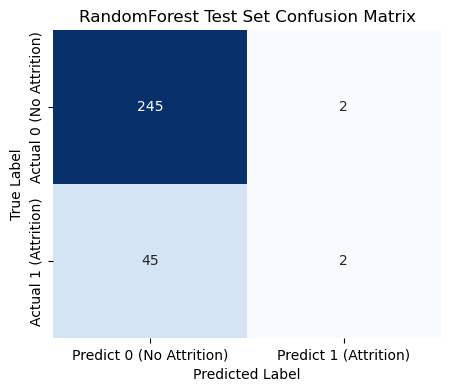

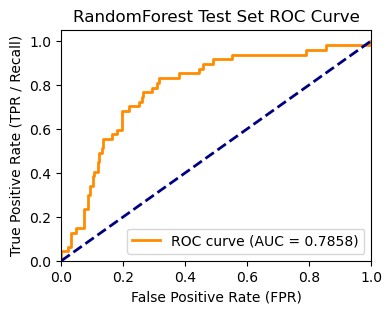

In [10]:
model_name_rf = 'RandomForest'
best_rf_model, best_rf_params = model_train(
    model_name_rf,
    X_train, y_train,
    X_test, y_test
)

model_evaluation(
    best_rf_model,
    X_train, y_train,
    X_test, y_test,
    model_name_rf
)

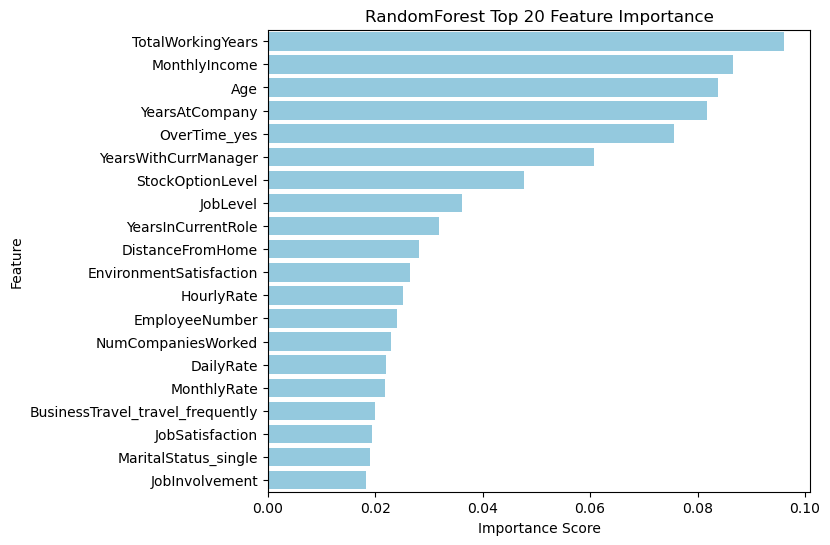

In [13]:
rf_feature_importance = feature_importance(
    best_rf_model,
    X_train,
    model_name_rf,
    top_n=20
)

In [14]:
# rf筛出来的top特征
rf_feature_list = rf_feature_importance['Feature'].tolist()
rf_feature_list

['TotalWorkingYears',
 'MonthlyIncome',
 'Age',
 'YearsAtCompany',
 'OverTime_yes',
 'YearsWithCurrManager',
 'StockOptionLevel',
 'JobLevel',
 'YearsInCurrentRole',
 'DistanceFromHome',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'EmployeeNumber',
 'NumCompaniesWorked',
 'DailyRate',
 'MonthlyRate',
 'BusinessTravel_travel_frequently',
 'JobSatisfaction',
 'MaritalStatus_single',
 'JobInvolvement']

## **2.3 XGBoost**

---训练模型: XGBoost ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits

 Grid Search 最佳参数: {'alpha': 0.5, 'lambda': 0.1, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 1000}

 交叉验证最佳 AUC-ROC: 0.8004
XGBoost 模型完整训练完成

---XGBoost 性能评估 ---

 Training Set Metrics:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  AUC-ROC:   1.0000

 Testing Set Metrics:
  Accuracy:  0.8707
  Precision: 0.7143
  Recall:    0.3191
  F1-Score:  0.4412
  AUC-ROC:   0.7666

--- 测试集混淆矩阵 (Confusion Matrix) ---


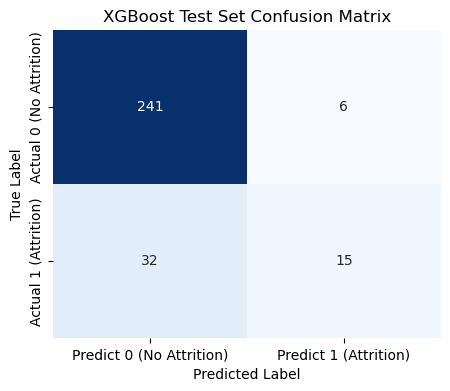

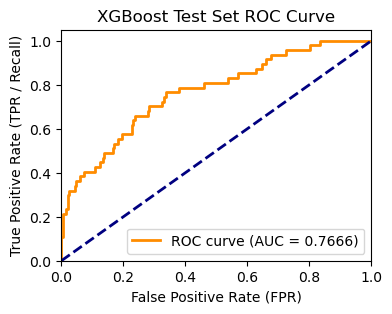

In [15]:
model_name_xgb = 'XGBoost'
best_xgb_model, best_xgb_params = model_train(
    model_name_xgb,
    X_train, y_train,
    X_test, y_test
)

model_evaluation(
    best_xgb_model,
    X_train, y_train,
    X_test, y_test,
    model_name_xgb
)

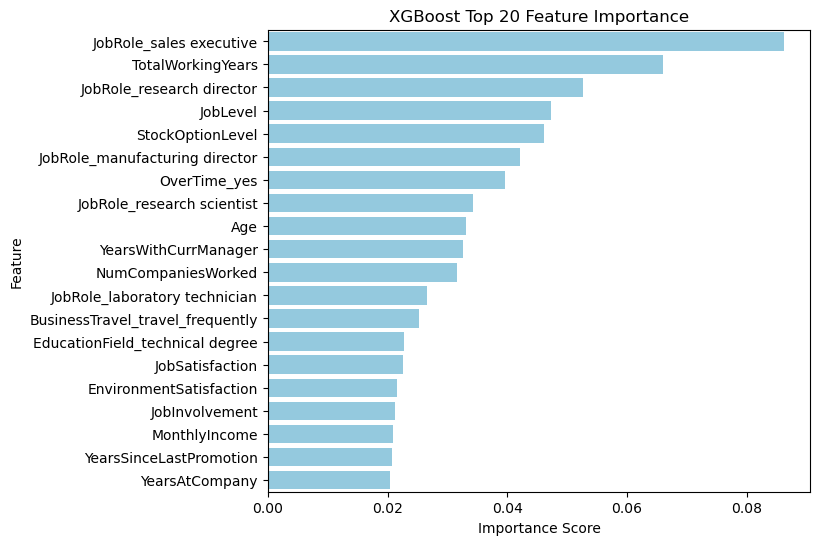

In [16]:
xgb_feature_importance = feature_importance(
    best_xgb_model,
    X_train,
    model_name_xgb,
    top_n=20
)

In [17]:
xgb_feature_importance

,Feature,Importance
35,JobRole_sales executive,0.086273
17,TotalWorkingYears,0.065935
33,JobRole_research director,0.052570
8,JobLevel,0.047320
16,StockOptionLevel,0.046151
32,JobRole_manufacturing director,0.042075
39,OverTime_yes,0.039665
34,JobRole_research scientist,0.034190
0,Age,0.033174
23,YearsWithCurrManager,0.032523


In [18]:
# XGBoost筛出来的top特征
xgb_feature_list = xgb_feature_importance['Feature'].tolist()
xgb_feature_list

['JobRole_sales executive',
 'TotalWorkingYears',
 'JobRole_research director',
 'JobLevel',
 'StockOptionLevel',
 'JobRole_manufacturing director',
 'OverTime_yes',
 'JobRole_research scientist',
 'Age',
 'YearsWithCurrManager',
 'NumCompaniesWorked',
 'JobRole_laboratory technician',
 'BusinessTravel_travel_frequently',
 'EducationField_technical degree',
 'JobSatisfaction',
 'EnvironmentSatisfaction',
 'JobInvolvement',
 'MonthlyIncome',
 'YearsSinceLastPromotion',
 'YearsAtCompany']

## **2.4 LightGBM**

---训练模型: LightGBM ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000217 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1411
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161565 -> initscore=-1.646632
[LightGBM] [Info] Start training from score -1.646632

 Grid Search 最佳参数: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'num_leaves': 10}

 交叉验证最佳 AUC-ROC: 0.8061
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 152, number of negative: 788
[LightGBM] [

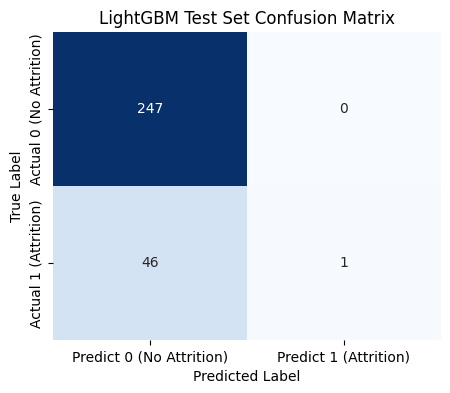

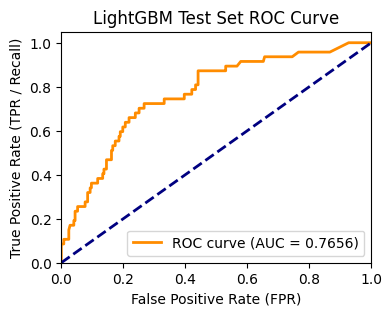

In [36]:
model_name_lgb = 'LightGBM'
best_lgb_model, best_lgb_params = model_train(
    model_name_lgb,
    X_train, y_train,
    X_test, y_test
)

model_evaluation(
    best_lgb_model,
    X_train, y_train,
    X_test, y_test,
    model_name_lgb
)

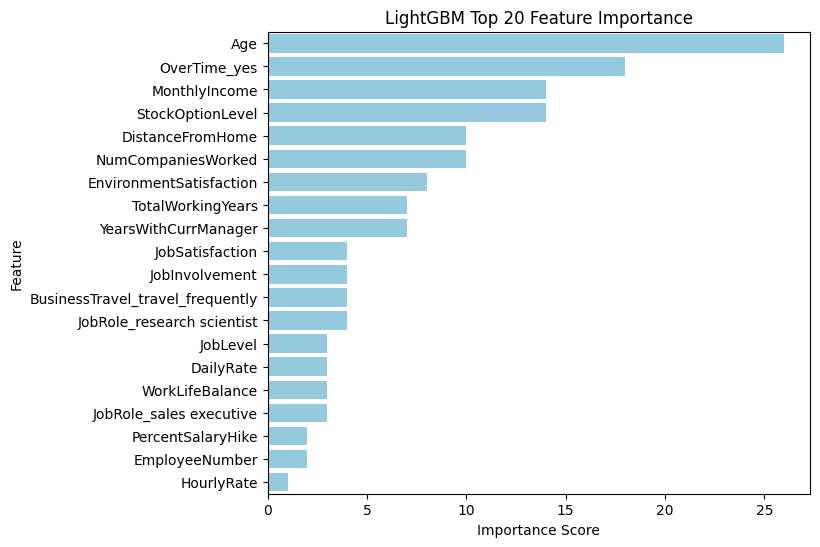

['Age',
 'OverTime_yes',
 'MonthlyIncome',
 'StockOptionLevel',
 'DistanceFromHome',
 'NumCompaniesWorked',
 'EnvironmentSatisfaction',
 'TotalWorkingYears',
 'YearsWithCurrManager',
 'JobSatisfaction',
 'JobInvolvement',
 'BusinessTravel_travel_frequently',
 'JobRole_research scientist',
 'JobLevel',
 'DailyRate',
 'WorkLifeBalance',
 'JobRole_sales executive',
 'PercentSalaryHike',
 'EmployeeNumber',
 'HourlyRate']

In [39]:
lgb_feature_importance = feature_importance(
    best_lgb_model,
    X_train,
    model_name_lgb,
    top_n=20
)
lgb_feature_list = lgb_feature_importance['Feature'].tolist()
lgb_feature_list

## **2.5 SVM**

---训练模型: SVM ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits

 Grid Search 最佳参数: {'C': 1, 'gamma': 'scale'}

 交叉验证最佳 AUC-ROC: 0.8119
SVM 模型完整训练完成

---SVM 性能评估 ---

 Training Set Metrics:
  Accuracy:  0.9379
  Precision: 0.7407
  Recall:    0.9474
  F1-Score:  0.8314
  AUC-ROC:   0.9789

 Testing Set Metrics:
  Accuracy:  0.8163
  Precision: 0.4426
  Recall:    0.5745
  F1-Score:  0.5000
  AUC-ROC:   0.7949

--- 测试集混淆矩阵 (Confusion Matrix) ---


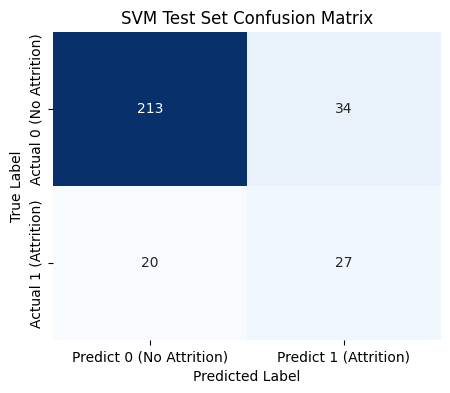

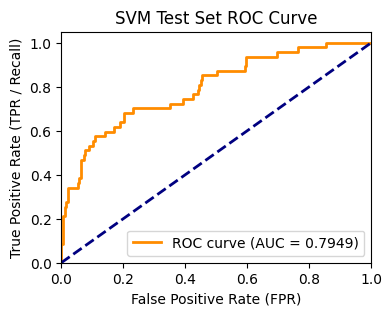

In [37]:
model_name_svm = 'SVM'
best_svm_model, best_svm_params = model_train(
    model_name_svm,
    X_train, y_train,
    X_test, y_test
)

model_evaluation(
    best_svm_model,
    X_train, y_train,
    X_test, y_test,
    model_name_svm
)

## **2.6 Feature Visualization**

In [40]:
# 分析特征重叠度
rf_set = set(rf_feature_list)
xgb_set = set(xgb_feature_list)
lgb_set = set(lgb_feature_list)

In [43]:
# 集合求交集
core_features = rf_set.intersection(lgb_set, xgb_set)
print(f"三个模型共同的 Top 20 特征数量: {len(core_features)}")
print(f"核心特征列表: {list(core_features)}")

rf_lgb_overlap = rf_set.intersection(lgb_set)
rf_xgb_overlap = rf_set.intersection(xgb_set)
lgb_xgb_overlap = lgb_set.intersection(xgb_set)

print(f"RF 和 LGB 共同特征数量: {len(rf_lgb_overlap)}")
print(f"RF 和 XGBoost 共同特征数量: {len(rf_xgb_overlap)}")
print(f"LGB 和 XGBoost 共同特征数量: {len(lgb_xgb_overlap)}")

三个模型共同的 Top 20 特征数量: 11
核心特征列表: ['JobInvolvement', 'EnvironmentSatisfaction', 'Age', 'TotalWorkingYears', 'JobSatisfaction', 'MonthlyIncome', 'JobLevel', 'OverTime_yes', 'StockOptionLevel', 'YearsWithCurrManager', 'NumCompaniesWorked']
RF 和 LGB 共同特征数量: 16
RF 和 XGBoost 共同特征数量: 12
LGB 和 XGBoost 共同特征数量: 14


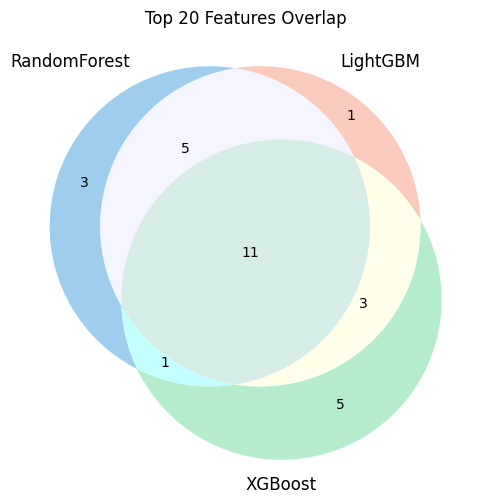

In [48]:
from matplotlib_venn import venn3

def plot_feature_overlap(rf_list, lgb_list, xgb_list, model_names):

    # 转换为集合
    rf_set = set(rf_list)
    lgb_set = set(lgb_list)
    xgb_set = set(xgb_list)

    plt.figure(figsize=(6, 6))
    NEW_COLORS = ('#5DADE2', '#F7A890', '#82E0AA')
    # 使用 venn3 绘制三个集合的图表
    venn3(
        subsets=(rf_set, lgb_set, xgb_set),
        set_labels=model_names,
        set_colors=NEW_COLORS,
        alpha=0.6,
        normalize_to=1.0
    )
    plt.title(f"Top {len(rf_list)} Features Overlap")
    plt.savefig("plt/feature_overlap.png", dpi=300, bbox_inches='tight')
    plt.show()

model_names = ('RandomForest', 'LightGBM', 'XGBoost')
plot_feature_overlap(rf_feature_list, lgb_feature_list, xgb_feature_list, model_names)

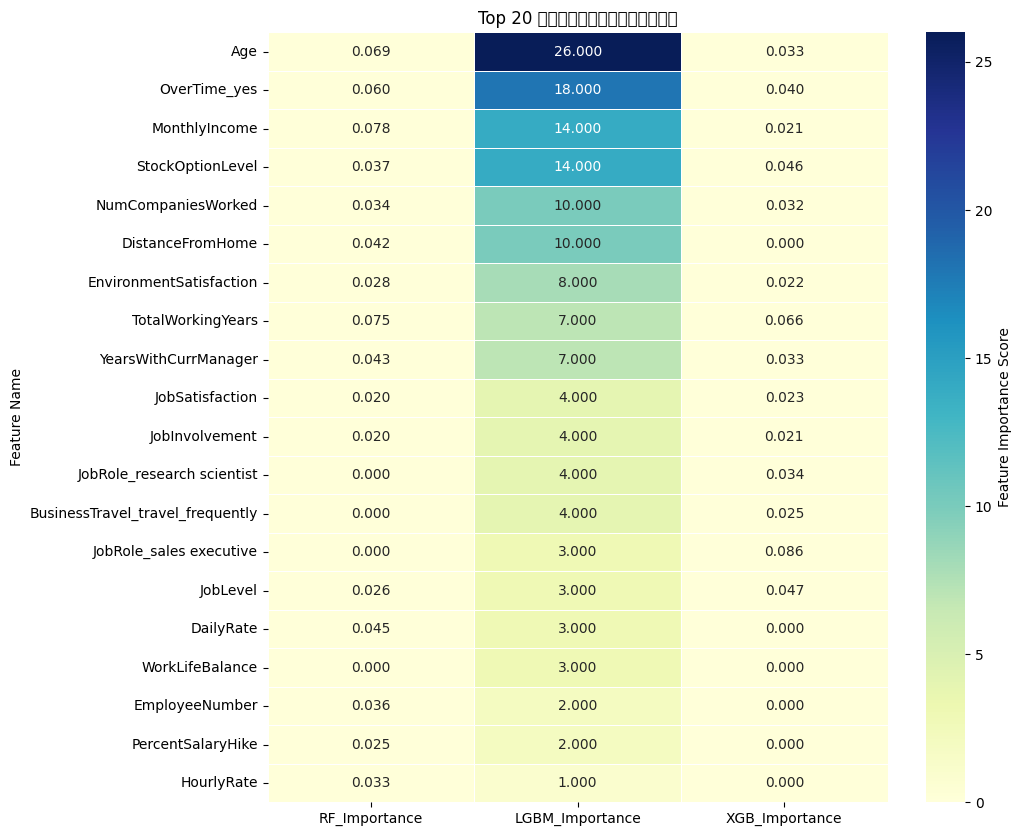

In [54]:
def create_combined_importance_df(rf_df, lgb_df, xgb_df):

    # 重命名重要性列，避免冲突
    rf_df = rf_df.rename(columns={'Importance': 'RF_Importance'})
    lgb_df = lgb_df.rename(columns={'Importance': 'LGBM_Importance'})
    xgb_df = xgb_df.rename(columns={'Importance': 'XGB_Importance'})

    # 使用 'Feature' 列进行外连接 (Outer Merge)，确保所有特征都在结果中
    combined_df = pd.merge(rf_df, lgb_df, on='Feature', how='outer')
    combined_df = pd.merge(combined_df, xgb_df, on='Feature', how='outer')

    # 填充 NaN 为 0 (表示该特征不在 Top N 中)
    combined_df = combined_df.fillna(0)

    return combined_df

# 假设您已经获取了三个模型的特征重要性 DataFrame：
combined_importance = create_combined_importance_df(rf_feature_importance, lgb_feature_importance, xgb_feature_importance)

def plot_importance_heatmap(combined_df, top_features_to_show=30):

    # 筛选出重要性总和最高的 Top features_to_show 个特征
    combined_df['Total_Importance'] = combined_df[['RF_Importance', 'LGBM_Importance', 'XGB_Importance']].sum(axis=1)

    # 按总重要性降序排列，并选择 Top N
    plot_data = combined_df.sort_values(by='Total_Importance', ascending=False).head(top_features_to_show)

    # 仅选择重要性列用于绘图
    plot_matrix = plot_data[['RF_Importance', 'LGBM_Importance', 'XGB_Importance']].set_index(plot_data['Feature'])

    plt.figure(figsize=(10, 10))

    sns.heatmap(
        plot_matrix,
        annot=True,        # 显示数值
        fmt=".3f",         # 保留三位小数
        cmap="YlGnBu",     # 配色方案
        linewidths=.5,     # 网格线
        cbar_kws={'label': 'Feature Importance Score'}
    )
    plt.title(f'Top {top_features_to_show} 特征在不同模型中的重要性对比')
    plt.ylabel('Feature Name')
    plt.show()


plot_importance_heatmap(combined_importance, top_features_to_show=20)

# **3. Hybrid Model -- Lasso+X**
将Lasso筛选出来的变量输入到机器学习模型中，观察预测效果是否有提升。

In [19]:
# Lasso筛选的变量
lasso_feature = ['Age', 'DailyRate', 'DistanceFromHome', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_travel_frequently', 'BusinessTravel_travel_rarely', 'Department_research & development', 'Gender_male', 'JobRole_laboratory technician', 'JobRole_research director', 'JobRole_sales representative', 'MaritalStatus_married', 'MaritalStatus_single', 'OverTime_yes', 'EducationField_life sciences', 'EducationField_marketing', 'EducationField_medical', 'EducationField_other', 'EducationField_technical degree']
print(f"Lasso筛选的变量数量: {len(lasso_feature)}")
print(f"原始的特征变量数量: {X_train.shape[1]}")

Lasso筛选的变量数量: 38
原始的特征变量数量: 45


In [87]:
# 重构训练集测试集
X_train_lasso = X_train[lasso_feature]
X_test_lasso = X_test[lasso_feature]

In [88]:
X_resampled_lasso = X_resampled[lasso_feature]
y_resampled_lasso = y_resampled

## **3.1 Lasso-RF**

---训练模型: RandomForest ---
Fitting 5 folds for each of 1 candidates, totalling 5 fits

 Grid Search 最佳参数: {'max_depth': 4}

 交叉验证最佳 AUC-ROC: 0.7800
RandomForest 模型完整训练完成

---RandomForest 性能评估 ---

 Training Set Metrics:
  Accuracy:  0.8699
  Precision: 0.9744
  Recall:    0.2000
  F1-Score:  0.3319
  AUC-ROC:   0.8877

 Testing Set Metrics:
  Accuracy:  0.8401
  Precision: 0.5000
  Recall:    0.0638
  F1-Score:  0.1132
  AUC-ROC:   0.7815

--- 测试集混淆矩阵 (Confusion Matrix) ---


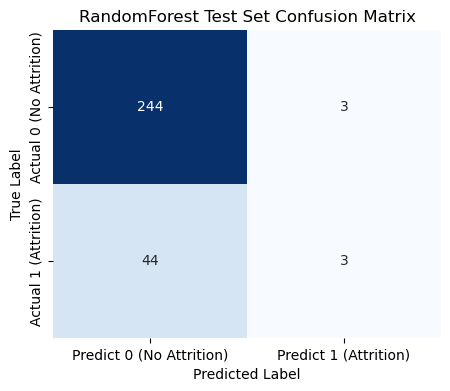

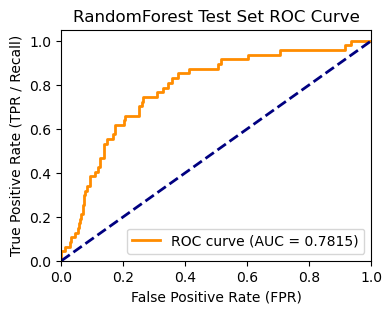

In [21]:
# 建立随机森林模型
model_name_lasso_rf = 'RandomForest'
best_lasso_rf_model, best_lasso_rf_params = model_train(
    model_name_lasso_rf,
    X_train_lasso, y_train,
    X_test_lasso, y_test
)

model_evaluation(
    best_lasso_rf_model,
    X_train_lasso, y_train,
    X_test_lasso, y_test,
    model_name_lasso_rf
)

# **4. Sample Balance**

## **4.1 Oversampling**

In [44]:
!pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imblearn]


In [86]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"原始训练集样本数量: {X_train.shape[0]}")
print("流失类别分布:")
print(Counter(y_train))

# 初始化 SMOTE 对象
smote = SMOTE(sampling_strategy=0.85, random_state=42)

# 注意只在训练集上应用 SMOTE，测试集保持不变
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print(f"SMOTE后训练集样本数量: {X_resampled.shape[0]}")
print("流失类别分布:")
print(Counter(y_resampled))

原始训练集样本数量: 1249
流失类别分布:
Counter({False: 1048, True: 201})
SMOTE后训练集样本数量: 1938
流失类别分布:
Counter({False: 1048, True: 890})


In [ ]:
# 初始化新的逻辑回归模型
logreg_smote = LogisticRegression(random_state=42)

# 使用平衡后的数据训练模型
logreg_smote.fit(X_resampled, y_resampled)

# 在原始的、未平衡的测试集上进行预测
y_pred_smote = logreg_smote.predict(X_test)
y_prob_smote = logreg_smote.predict_proba(X_test)[:, 1]

# 评估
print("\n--- 逻辑回归（SMOTE后）在测试集上的评估 ---")
accuracy = accuracy_score(y_test, y_pred_smote)
precision = precision_score(y_test, y_pred_smote)
recall = recall_score(y_test, y_pred_smote)
f1 = f1_score(y_test, y_pred_smote)
auc_roc = roc_auc_score(y_test, y_prob_smote)

print(f"Accuracy (准确率): {accuracy:.4f}")
print(f"Precision (精确率): {precision:.4f}")
print(f"Recall (召回率): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

原始训练集样本数量: 1176
流失类别分布:
Counter({False: 986, True: 190})
SMOTE后训练集样本数量: 1972
流失类别分布:
Counter({False: 986, True: 986})

--- 逻辑回归（SMOTE后）在测试集上的评估 ---
Accuracy (准确率): 0.8537
Precision (精确率): 0.5476
Recall (召回率): 0.4894
F1-Score: 0.5169
AUC-ROC: 0.8102


## **4.2 Undersampling**

In [19]:
from imblearn.under_sampling import RandomUnderSampler

print(f"原始训练集样本数量: {X_train.shape[0]}")
print("流失类别分布:")
print(Counter(y_train))

# 初始化 RandomUnderSampler 对象
rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)

# 在训练集上应用欠采样
X_undersampled, y_undersampled = rus.fit_resample(X_train, y_train)

print(f"欠采样后训练集样本数量: {X_undersampled.shape[0]}")
print("流失类别分布:")
print(Counter(y_undersampled))


# 初始化新的逻辑回归模型
logreg_rus = LogisticRegression(random_state=42)

# 使用欠采样后的数据训练模型
logreg_rus.fit(X_undersampled, y_undersampled)

# 在原始的、未平衡的测试集上进行预测
y_pred_rus = logreg_rus.predict(X_test)
y_prob_rus = logreg_rus.predict_proba(X_test)[:, 1]

# 评估
print("\n--- 逻辑回归（欠采样后）在测试集上的评估 ---")
accuracy = accuracy_score(y_test, y_pred_rus)
precision = precision_score(y_test, y_pred_rus)
recall = recall_score(y_test, y_pred_rus)
f1 = f1_score(y_test, y_pred_rus)
auc_roc = roc_auc_score(y_test, y_prob_rus)

print(f"Accuracy (准确率): {accuracy:.4f}")
print(f"Precision (精确率): {precision:.4f}")
print(f"Recall (召回率): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

原始训练集样本数量: 1176
流失类别分布:
Counter({False: 986, True: 190})
欠采样后训练集样本数量: 380
流失类别分布:
Counter({False: 190, True: 190})

--- 逻辑回归（欠采样后）在测试集上的评估 ---
Accuracy (准确率): 0.7381
Precision (精确率): 0.3370
Recall (召回率): 0.6596
F1-Score: 0.4460
AUC-ROC: 0.7778
